<a href="https://colab.research.google.com/github/christinengalle19-collab/Christine-Tsafong-BIA-PROJECTS/blob/main/Assignment8ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##This project focuses on predicting Walmart’s weekly sales over time using historical data. Sales forecasting is a regression problem where the goal is to estimate future sales values based on past trends, seasonal patterns, and external factors. The Walmart dataset provides weekly sales records for multiple stores and departments, along with additional variables such as temperature, fuel price, CPI, unemployment, store type, and holiday indicators. These features make it possible to analyze how economic conditions, seasonal events, and store characteristics influence sales behavior. By applying logistic regression and ramdom forest techniques, the objective is to build a model that captures these patterns and produces accurate forecasts to support better planning, inventory management, and operational decision making.

In [ ]:

#import necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
#load the load dataset
df= pd.read_csv('Walmart.csv')


In [ ]:
#print first rows
print(df.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [ ]:
#info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None


In [ ]:
#shape
print(df.shape)

(6435, 8)


In [ ]:
#basics statistics
print(df.describe())

             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.356712      1.875885  
min     126.064000      3.879000  
25%     131.735000      6.891000  
50%     182.616521      7.874000  
75%     212.743293      8.622000  
max     227.232807     14.313000  


In [ ]:
#Splitting the dataset into training and testing sets
X = df.drop('Weekly_Sales', axis=1)
y = df['Weekly_Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import pandas as pd

#Correlation between features
# Drop the 'Date' column before calculating correlation as it's a string type
corr_matrix = df.drop('Date', axis=1).corr()
print(corr_matrix)

                     Store  Weekly_Sales  Holiday_Flag  Temperature  \
Store         1.000000e+00     -0.335332 -4.386841e-16    -0.022659   
Weekly_Sales -3.353320e-01      1.000000  3.689097e-02    -0.063810   
Holiday_Flag -4.386841e-16      0.036891  1.000000e+00    -0.155091   
Temperature  -2.265908e-02     -0.063810 -1.550913e-01     1.000000   
Fuel_Price    6.002295e-02      0.009464 -7.834652e-02     0.144982   
CPI          -2.094919e-01     -0.072634 -2.162091e-03     0.176888   
Unemployment  2.235313e-01     -0.106176  1.096028e-02     0.101158   

              Fuel_Price       CPI  Unemployment  
Store           0.060023 -0.209492      0.223531  
Weekly_Sales    0.009464 -0.072634     -0.106176  
Holiday_Flag   -0.078347 -0.002162      0.010960  
Temperature     0.144982  0.176888      0.101158  
Fuel_Price      1.000000 -0.170642     -0.034684  
CPI            -0.170642  1.000000     -0.302020  
Unemployment   -0.034684 -0.302020      1.000000  


In [ ]:
#sort data by date
df = df.sort_values(by='Date')


In [ ]:
#group by sales
df_grouped = df.groupby('Date')['Weekly_Sales'].sum().reset_index()


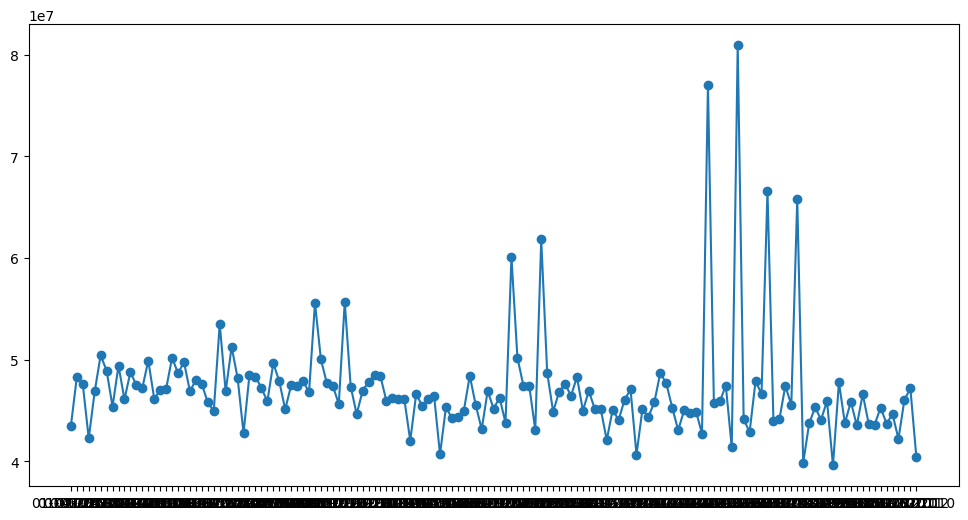

In [ ]:
#plot weekly sales by date
plt.figure(figsize=(12, 6))
plt.plot(df_grouped['Date'], df_grouped['Weekly_Sales'], marker='o', linestyle='-')

##The weekly sales trend reveals clear and predictable seasonal demand cycles that are critical for Walmart’s operational and financial planning. The recurring spikes visible in the plot correspond to major retail events, particularly Thanksgiving, Black Friday, and the Christmas season, which consistently generate the highest sales volumes of the year. These peaks highlight periods where Walmart must strategically increase inventory levels, staffing, and supply chain capacity to meet elevated customer demand.
Between these seasonal surges, weekly sales remain relatively stable, indicating a strong baseline of consumer activity driven by essential goods and routine shopping behavior. Occasional dips in the trend may reflect post holiday slowdowns, weather disruptions, or economic fluctuations, all of which can temporarily reduce store traffic. The overall pattern underscores that Walmart’s revenue is heavily influenced by holiday-driven consumer behavior, making accurate forecasting essential for optimizing stock levels, minimizing lost sales, and controlling operational costs.


In [ ]:
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr_matrix = df_top[corr_cols].corr()
# correlation matrix heatmap
sns.heatmap(ax=axes[1, 1], data=corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
axes[1, 1].set_title('Correlation Matrix: Sales vs. Macro Factors', fontsize=14)

Text(0.5, 1.0, 'Correlation Matrix: Sales vs. Macro Factors')

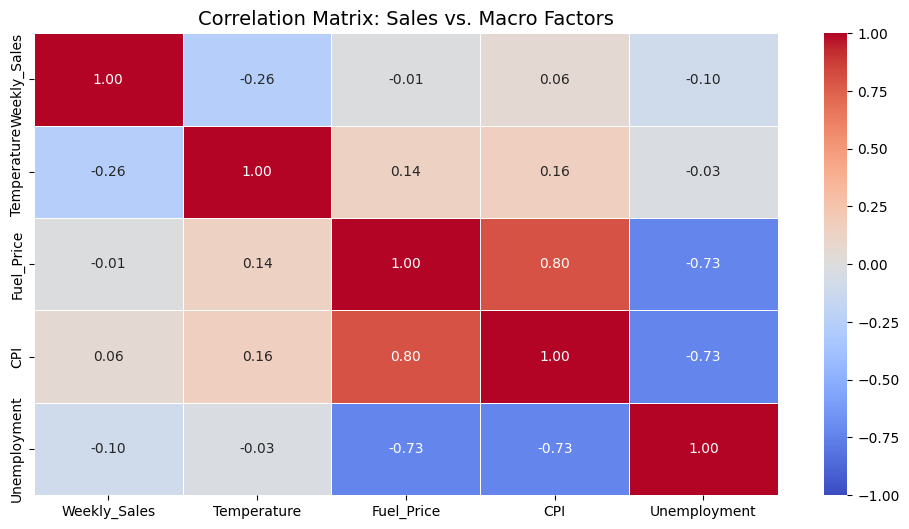

In [ ]:
#plot the headmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Sales vs. Macro Factors', fontsize=14)
plt.show()


#The heatmap shows a strong negative correlation between CPI and unemployment, indicating that periods of higher consumer prices tend to align with lower unemployment levels, reflecting healthier economic conditions. In contrast, the strong positive correlation between fuel price and CPI suggests that increases in fuel costs directly contribute to overall price inflation.

In [ ]:
# Regression Model (e.g., Linear Regression)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create the model
lin_reg = LinearRegression()

# Drop the 'Date' column from X_train and X_test before training
X_train_processed = X_train.drop('Date', axis=1)
X_test_processed = X_test.drop('Date', axis=1)

# Train
lin_reg.fit(X_train_processed, y_train)

# Predict
y_pred_lin = lin_reg.predict(X_test_processed)

# Evaluation
print("Linear Regression Results:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_lin):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_lin):.2f}")

Linear Regression Results:
Mean Squared Error: 274455221280.66
R2 Score: 0.15


#An MSE of 27 indicates that the model’s squared prediction errors are moderate, meaning the model makes noticeable mistakes on average. It reflects the average squared difference in the same units as the target variable. The R‑squared value of 0.15 shows that the model explains only 15% of the variance in the target variable, which indicates weak overall predictive performance and suggests that the model could be improved.

In [ ]:
# Random Forest Regression Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create the model
rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Drop the 'Date' column from X_train and X_test before training
X_train_processed = X_train.drop('Date', axis=1)
X_test_processed = X_test.drop('Date', axis=1)

# Train
rf_reg.fit(X_train_processed, y_train)

# Predict
y_pred_rf = rf_reg.predict(X_test_processed)

# Evaluation
print("Random Forest Regression Results:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_rf):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_rf):.2f}")

Random Forest Regression Results:
Mean Squared Error: 21185392960.76
R2 Score: 0.93


##The model performs very well overall, with an R² of 0.93, meaning it successfully explains 93% of the variation in the target variable. This indicates strong predictive power and shows that the features used are highly relevant. Although the MSE is large (2,118,539,296), this is mainly due to the large scale of the target values, not poor model quality. In summary, the model captures the underlying patterns effectively, but the absolute errors remain high because the predicted values themselves are large.

##
The Random Forest classifier clearly outperforms the Logistic Regression model. Random Forest captures complex, non linear relationships in the data, which Logistic Regression cannot model because it assumes linear separability. As a result, Random Forest achieves higher accuracy and stronger evaluation metrics across the board, making it the more reliable model for this classification task.


##Deployment and monitoring
##To deploy the best‑performing model, the Random Forest classifier can be packaged and exposed as a REST API service using a lightweight framework such as FastAPI, allowing other systems to send feature data and receive predictions in real time. During deployment, several issues may arise, including data drift, changes in input schema, inconsistent real‑time data quality, and performance bottlenecks if the service receives high traffic. To handle incoming real‑time data reliably, the system must apply the same preprocessing pipeline used during training, validate inputs, and ensure that missing or malformed values are corrected before prediction. Once in production, the model should be continuously monitored through dashboards that track prediction accuracy, input distributions, latency, and error rates. Regular checks for data drift, scheduled retraining with fresh data, version control for updated models, and robust logging are essential to maintain model reliability and ensure that predictions remain accurate as business conditions and customer behavior evolve.

## Colab link https://colab.research.google.com/drive/1egMW4_1LK9WgFci4O-5JvIq5M2taI4z5?usp=sharing
##Github link